# Friedkin-Johnsen Bias Variants 

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Matplotlib is building the font cache; this may take a moment.


In [3]:
import hashlib

ROOT = Path('/home/sammli/llm-network')
if not ROOT.exists():
    ROOT = Path('/Users/samuelli/Documents/code/llm/llm-network')
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'
RECENT_RUNS = RUN_DIRS[-3:]
assert len(RECENT_RUNS) == 3, f'Expected at least 3 runs, found {len(RUN_DIRS)}'
LATEST_RUN = RECENT_RUNS[-1]

PARAMS = {
    'lambda_grid': [0.2, 0.4, 0.6, 0.8],
    # Experiment 1: b_i = clip(beta0 + beta_assigned*(assigned_i-0.5)
    #                          + beta_profile*(profile_i-0.5) + beta_init*(init_i-0.5) + eps_i, 0, 1)
    'beta0_grid': np.linspace(0.2, 0.8, 7).tolist(),
    'beta_assigned_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    'beta_profile_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    'beta_init_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    # Small deterministic noise injection in Experiment 1.
    'exp1_noise_std': 0.01,
    'noise_seed': 23,
    # Experiment 2: additive upward lift delta added to each agent's initial opinion.
    'bias_lift_grid': np.linspace(0.0, 0.35, 15).tolist(),
    # Train/plot windows focused on early dynamics including initialization and approach to convergence.
    'exp1_eval_horizon': 20,
    'exp1_plot_horizon': 20,
    'exp2_eval_horizon': 20,
    'exp2_plot_horizon': 20,
}

print('Using recent runs for fitting (first 20 slices for both experiments):')
for r in RECENT_RUNS:
    print(' ', r.name)
print('Plotting only latest run:', LATEST_RUN.name)


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def to_unit_interval(x):
    x = np.asarray(x, dtype=float)
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def from_unit_interval(z):
    z = np.asarray(z, dtype=float)
    return np.clip(2.0 * z - 1.0, -1.0, 1.0)


def deterministic_noise(run_name: str, agent_id: str, std: float, seed: int):
    if std <= 0:
        return 0.0
    token = f"{run_name}|{agent_id}|{seed}".encode('utf-8')
    h = hashlib.sha256(token).hexdigest()
    local_seed = int(h[:16], 16) % (2**32 - 1)
    rng = np.random.default_rng(local_seed)
    return float(rng.normal(0.0, std))


def build_slice_observations(run_dir: Path):
    profile_by_agent_slice = defaultdict(lambda: defaultdict(list))
    first_self_posts = {}

    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}, {}, 0

    max_time_slice = 0
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            # Profile observation (target): topology profile ss by time slice.
            slice_idx = row.get('matched_topology_snapshot_time_slice', row.get('message_time_slice'))
            topo = row.get('topology_profile_for_agent', {}) or {}
            obs_ss = topo.get('ss', None)
            if slice_idx is not None and obs_ss is not None:
                slice_idx = int(slice_idx)
                profile_by_agent_slice[agent_id][slice_idx].append(float(obs_ss))
                max_time_slice = max(max_time_slice, slice_idx)

            # Initialization proxy from first self-post expression.
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue

            candidate = {
                'time_slice': int(msg_slice),
                'stance_score': float(pub),
                'message_index': int(msg_index),
            }
            existing = first_self_posts.get(agent_id)
            if existing is None or (candidate['time_slice'], candidate['message_index']) < (existing['time_slice'], existing['message_index']):
                first_self_posts[agent_id] = candidate

    profile_by_agent_slice = {
        agent: {ts: float(np.mean(vals)) for ts, vals in ts_map.items()}
        for agent, ts_map in profile_by_agent_slice.items()
    }

    return profile_by_agent_slice, first_self_posts, int(max_time_slice)


def load_run_data(run_dir: Path):
    graph = get_graph_adjacency(load_json(run_dir / 'connection_graph.json'))
    profile_by_agent_slice, first_self_posts, max_time_slice = build_slice_observations(run_dir)

    static_init_path = run_dir / 'static_init.json'
    static_init = load_json(static_init_path) if static_init_path.exists() else {}
    stance_weights = static_init.get('stance_weights', {}) or {}

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)
    agent_ids.update(profile_by_agent_slice.keys())
    agent_ids.update(first_self_posts.keys())
    agent_ids.update([parse_agent_id(a) for a in stance_weights.keys() if parse_agent_id(a) is not None])
    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    # Assigned initialization on [-1, 1] from static_init (if present).
    assigned_init_unit = {}
    for a in agent_ids:
        w = stance_weights.get(a, None)
        if w is None:
            assigned_init_unit[a] = np.nan
        else:
            assigned_init_unit[a] = float(to_unit_interval(float(w)))

    return {
        'run_name': run_dir.name,
        'graph': graph,
        'agent_ids': agent_ids,
        'profile_by_agent_slice': profile_by_agent_slice,
        'first_self_posts': first_self_posts,
        'assigned_init_unit': assigned_init_unit,
        'max_time_slice': int(max_time_slice),
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def build_W_for_fj(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx


def initial_signals(data):
    assigned = {}
    profile_init = {}
    init_post = {}
    base_x0 = {}

    for a in data['agent_ids']:
        # Assigned init from static init if available.
        ai = data['assigned_init_unit'].get(a, np.nan)
        assigned[a] = float(ai) if np.isfinite(float(ai)) else np.nan

        # Profile-based initial observation (slice 0 if possible).
        profile_map = data['profile_by_agent_slice'].get(a, {})
        if 0 in profile_map:
            p0_ss = float(profile_map[0])
        elif profile_map:
            first_slice = min(profile_map)
            p0_ss = float(profile_map[first_slice])
        elif np.isfinite(float(ai)):
            p0_ss = float(from_unit_interval(ai))
        else:
            p0_ss = 0.0
        profile_init[a] = float(to_unit_interval(p0_ss))

        # First self-post init if present, else fallback to profile init.
        fs = data['first_self_posts'].get(a)
        if fs is not None:
            init_ss = float(fs['stance_score'])
            init_post[a] = float(to_unit_interval(init_ss))
        else:
            init_post[a] = float(profile_init[a])

        # Fill missing assigned from profile init for stable deterministic initialization.
        if not np.isfinite(float(assigned[a])):
            assigned[a] = float(profile_init[a])

        # Existing initial opinion used by global-bias mixture model.
        base_x0[a] = float(np.clip(0.85 * assigned[a] + 0.15 * profile_init[a], 0.0, 1.0))

    return assigned, profile_init, init_post, base_x0


def run_fj_with_x0(data, lam, x0_unit_dict):
    """Experiment 1 dynamics: z(t+1) = lam*x0 + (1-lam)*Wz(t)."""
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    z0 = np.array([float(x0_unit_dict[a]) for a in agent_ids], dtype=float)
    z = z0.copy()

    records = []
    max_slice = int(data['max_time_slice'])
    for time_slice in range(0, max_slice + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(float(lam) * z0 + (1.0 - float(lam)) * social, 0.0, 1.0)

        for a in agent_ids:
            obs_map = data['profile_by_agent_slice'].get(a, {})
            has_obs = time_slice in obs_map
            if has_obs:
                obs_ss = float(obs_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
            else:
                obs_ss = np.nan
                obs_unit = np.nan

            pred_unit = float(z[idx[a]])
            records.append(
                {
                    'run': data['run_name'],
                    'time_slice': int(time_slice),
                    'agent': a,
                    'pred_unit': pred_unit,
                    'obs_unit': obs_unit,
                    'pred_ss': float(from_unit_interval(pred_unit)),
                    'obs_ss': float(obs_ss) if np.isfinite(obs_ss) else np.nan,
                    'has_obs': bool(has_obs),
                }
            )

    return {
        'records': records,
        'z0': {a: float(x0_unit_dict[a]) for a in agent_ids},
        'W': W,
        'idx': idx,
    }


def run_fj_with_global_bias_lift(data, lam_social, bias_lift, base_x0_unit_dict):
    """Experiment 2 dynamics:
    z(0) = clip(x0 + delta, 0, 1),
    z(t+1) = lam_social * W z(t) + (1-lam_social) * clip(x0 + delta, 0, 1),
    where delta is the same upward lift applied to every agent.
    """
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    x0_base = np.array([float(base_x0_unit_dict[a]) for a in agent_ids], dtype=float)
    bias_lift_value = float(np.clip(float(bias_lift), 0.0, 1.0))
    anchor = np.clip(x0_base + bias_lift_value, 0.0, 1.0)

    # Apply the same upward lift to each agent while preserving relative differences.
    z = anchor.copy()

    records = []
    max_slice = int(data['max_time_slice'])
    for time_slice in range(0, max_slice + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(float(lam_social) * social + (1.0 - float(lam_social)) * anchor, 0.0, 1.0)

        for a in agent_ids:
            obs_map = data['profile_by_agent_slice'].get(a, {})
            has_obs = time_slice in obs_map
            if has_obs:
                obs_ss = float(obs_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
            else:
                obs_ss = np.nan
                obs_unit = np.nan

            pred_unit = float(z[idx[a]])
            records.append(
                {
                    'run': data['run_name'],
                    'time_slice': int(time_slice),
                    'agent': a,
                    'pred_unit': pred_unit,
                    'obs_unit': obs_unit,
                    'pred_ss': float(from_unit_interval(pred_unit)),
                    'obs_ss': float(obs_ss) if np.isfinite(obs_ss) else np.nan,
                    'has_obs': bool(has_obs),
                }
            )

    return {
        'records': records,
        'bias_lift_value': float(bias_lift_value),
        'anchor': {a: float(anchor[idx[a]]) for a in agent_ids},
        'x0_base': {a: float(base_x0_unit_dict[a]) for a in agent_ids},
        'W': W,
        'idx': idx,
    }


def evaluate_records(records, horizon=10):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan, 'n_eval': 0}

    df = pd.DataFrame(records)
    df = df[(df['has_obs']) & (df['time_slice'] <= int(horizon))].copy()
    if df.empty:
        return {'mae': np.nan, 'rmse': np.nan, 'n_eval': 0}

    d = (df['pred_unit'] - df['obs_unit']).to_numpy(dtype=float)
    return {
        'mae': float(np.mean(np.abs(d))),
        'rmse': float(np.sqrt(np.mean(d * d))),
        'n_eval': int(len(df)),
    }


def plot_all_agents(df, title, horizon=10):
    d = df[df['time_slice'] <= int(horizon)].copy()
    agent_order = sorted(d['agent'].unique(), key=numeric_agent_key)
    palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]

    plt.figure(figsize=(9.6, 5.4))
    for i, agent in enumerate(agent_order):
        dfa = d[d['agent'] == agent].sort_values('time_slice')
        dfa_obs = dfa[dfa['has_obs']].copy()

        base_rgb = np.asarray(palette[i][:3], dtype=float)
        obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb

        plt.plot(
            dfa_obs['time_slice'],
            dfa_obs['obs_unit'],
            color=(*obs_rgb, 0.40),
            linewidth=0.8,
            marker='o',
            markersize=1.8,
            solid_capstyle='round',
        )
        plt.plot(
            dfa['time_slice'],
            dfa['pred_unit'],
            color=(*base_rgb, 0.90),
            linewidth=1.35,
            solid_capstyle='round',
        )

    legend_handles = [
        Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=0.9, marker='o', markersize=3, label='observed slices'),
        Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.5, label='predicted'),
    ]
    plt.title(title)
    plt.xlabel('time slice')
    plt.ylabel('scaled stance score [0,1]')
    plt.ylim(0.0, 1.0)
    plt.xlim(0, max(1, int(horizon)))
    plt.legend(handles=legend_handles, loc='upper right', frameon=False)
    plt.tight_layout()
    plt.show()


RUN_DATA = {r.name: load_run_data(r) for r in RECENT_RUNS}
for rn, rd in RUN_DATA.items():
    n_profile_obs = sum(len(v) for v in rd['profile_by_agent_slice'].values())
    print(rn, 'agents=', len(rd['agent_ids']), 'max_time_slice=', rd['max_time_slice'], 'profile_obs=', n_profile_obs)

Using recent runs for fitting (first 20 slices for both experiments):
  run_20260315-193030
  run_20260315-194138
  run_20260315-195220
Plotting only latest run: run_20260315-195220
run_20260315-193030 agents= 30 max_time_slice= 8 profile_obs= 121
run_20260315-194138 agents= 30 max_time_slice= 9 profile_obs= 103
run_20260315-195220 agents= 30 max_time_slice= 9 profile_obs= 119


## Experiment 1: Agent-specific bias vector b_i

We learn a deterministic per-agent anchor from initialization signals/signals after a timeslice:

$$
b_i = \left(\beta_0 + \beta_a(a_i-0.5) + \beta_p(p_i-0.5) + \beta_i(s_i-0.5)\right)
$$

where:
- $a_i$ = assigned initial opinion from `static_init` (mapped to $[0,1]$)
- $p_i$ = profile-based initial opinion from early observed profile stance
- $s_i$ = first self-post initialization (mapped to $[0,1]$)
- $\epsilon_i$ = small deterministic noise term (seeded by run+agent)

Then FJ update is:

$$
z_i(t+1)=\lambda\,b_i + (1-\lambda)\,\sum_j W_{ij}z_j(t)
$$

Prediction objective: choose $(\lambda,\beta_0,\beta_a,\beta_p,\beta_i)$ that minimizes weighted RMSE over the **3 runs**, restricted to the **first 20 slices** with true observed profile stances.

,lambda,beta0,beta_assigned,beta_profile,beta_init,rmse,mae,n_eval
0,0.8,0.5,0.0,0.5,0.5,0.084936,0.062461,343
1,0.6,0.4,0.0,1.0,1.0,0.087787,0.066604,343
2,0.6,0.5,0.0,1.0,0.5,0.089680,0.070872,343
3,0.4,0.4,0.0,1.0,1.0,0.090237,0.069438,343
4,0.8,0.5,0.0,1.0,0.5,0.092017,0.072215,343
5,0.6,0.4,0.0,0.5,1.0,0.093384,0.073042,343
6,0.8,0.4,0.0,0.5,1.0,0.095249,0.076267,343
7,0.6,0.5,0.0,0.5,0.5,0.096476,0.077727,343
8,0.8,0.5,0.0,1.0,0.0,0.099384,0.059880,343
9,0.4,0.5,0.5,1.0,1.0,0.099818,0.077430,343


Best Experiment-1 params: {'lambda': 0.8, 'beta0': 0.5, 'beta_assigned': 0.0, 'beta_profile': 0.5, 'beta_init': 0.5, 'rmse': 0.08493617626442085, 'mae': 0.06246097035841688, 'n_eval': 343.0}


,agent,assigned_init,profile_init,first_post_init,base_existing_x0,bias_unit,bias_ss
0,agent_1,0.00,0.559203,0.653323,0.083880,0.614402,0.228803
1,agent_2,0.25,0.337898,0.545476,0.263185,0.420084,-0.159831
2,agent_3,0.50,0.608507,0.736643,0.516276,0.667923,0.335846
3,agent_4,0.25,0.675690,0.675690,0.313854,0.685662,0.371323
4,agent_5,0.75,0.754219,0.754219,0.750633,0.745024,0.490048
5,agent_6,0.50,0.608507,0.728429,0.516276,0.673276,0.346551
6,agent_7,0.75,0.785259,0.718797,0.755289,0.745679,0.491358
7,agent_8,0.00,0.511727,0.564312,0.076759,0.536599,0.073198
8,agent_9,0.00,0.519883,0.615604,0.077983,0.560221,0.120442
9,agent_10,1.00,0.772923,0.715934,0.965938,0.746282,0.492564


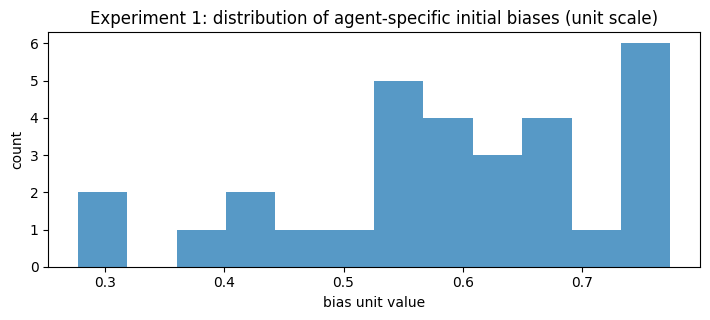

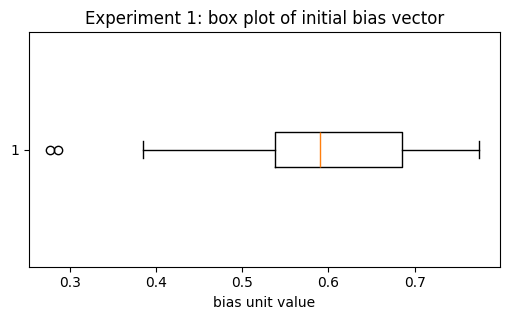

Experiment 1 latest-run metrics (first 20 slices): {'mae': 0.05900798693341296, 'rmse': 0.07630697568052565, 'n_eval': 119}


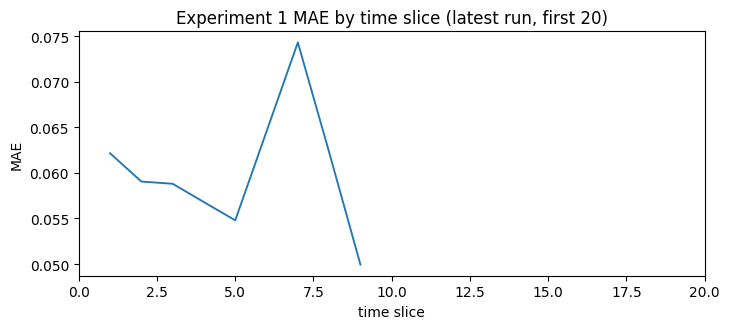

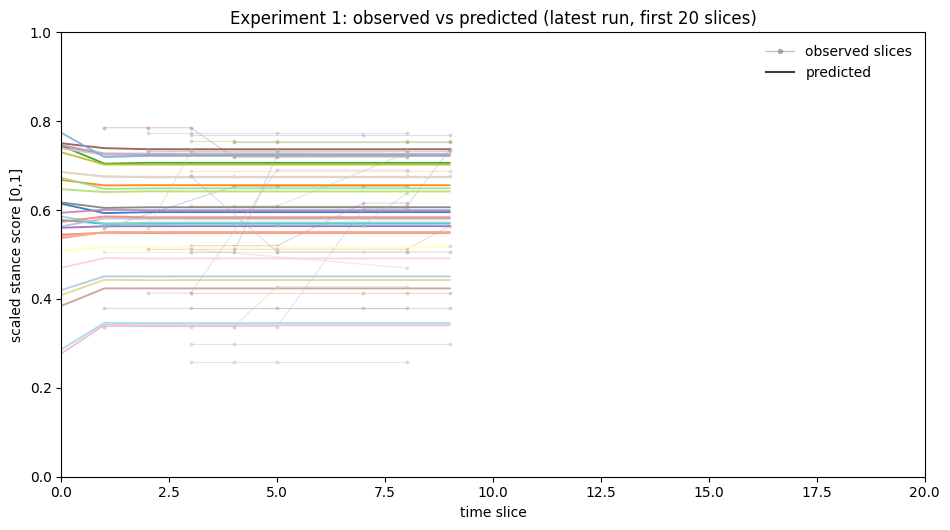

In [4]:
def build_agent_bias_vector(
    run_name,
    assigned_init,
    profile_init,
    init_post,
    beta0,
    beta_assigned,
    beta_profile,
    beta_init,
    noise_std=0.0,
    noise_seed=0,
):
    out = {}
    for a in assigned_init.keys():
        eps_i = deterministic_noise(run_name, a, std=float(noise_std), seed=int(noise_seed))
        bi = (
            beta0
            + beta_assigned * (assigned_init[a] - 0.5)
            + beta_profile * (profile_init[a] - 0.5)
            + beta_init * (init_post[a] - 0.5)
            + eps_i
        )
        out[a] = float(np.clip(bi, 0.0, 1.0))
    return out


rows = []
for lam in PARAMS['lambda_grid']:
    for beta0 in PARAMS['beta0_grid']:
        for b_assigned in PARAMS['beta_assigned_grid']:
            for b_profile in PARAMS['beta_profile_grid']:
                for b_init in PARAMS['beta_init_grid']:
                    run_metrics = []
                    for run_name, data in RUN_DATA.items():
                        assigned_init, profile_init, init_post, base_x0 = initial_signals(data)
                        x0 = build_agent_bias_vector(
                            run_name,
                            assigned_init,
                            profile_init,
                            init_post,
                            beta0,
                            b_assigned,
                            b_profile,
                            b_init,
                            noise_std=PARAMS['exp1_noise_std'],
                            noise_seed=PARAMS['noise_seed'],
                        )
                        out = run_fj_with_x0(data, lam=lam, x0_unit_dict=x0)
                        m = evaluate_records(out['records'], horizon=PARAMS['exp1_eval_horizon'])
                        run_metrics.append(m)

                    n_total = int(sum(m['n_eval'] for m in run_metrics))
                    if n_total == 0:
                        continue
                    w_rmse = float(np.sqrt(np.sum([(m['rmse'] ** 2) * m['n_eval'] for m in run_metrics]) / n_total))
                    w_mae = float(np.sum([m['mae'] * m['n_eval'] for m in run_metrics]) / n_total)
                    rows.append(
                        {
                            'lambda': float(lam),
                            'beta0': float(beta0),
                            'beta_assigned': float(b_assigned),
                            'beta_profile': float(b_profile),
                            'beta_init': float(b_init),
                            'rmse': w_rmse,
                            'mae': w_mae,
                            'n_eval': n_total,
                        }
                    )

exp1_res = pd.DataFrame(rows).sort_values(['rmse', 'mae']).reset_index(drop=True)
display(exp1_res.head(10))
best1 = exp1_res.iloc[0].to_dict()
print('Best Experiment-1 params:', best1)

latest_data = RUN_DATA[LATEST_RUN.name]
assigned_latest, profile_latest, init_latest, base_latest = initial_signals(latest_data)
x0_best_latest = build_agent_bias_vector(
    latest_data['run_name'],
    assigned_latest,
    profile_latest,
    init_latest,
    best1['beta0'],
    best1['beta_assigned'],
    best1['beta_profile'],
    best1['beta_init'],
    noise_std=PARAMS['exp1_noise_std'],
    noise_seed=PARAMS['noise_seed'],
)

bias_df = (
    pd.DataFrame(
        {
            'agent': list(x0_best_latest.keys()),
            'assigned_init': [assigned_latest[a] for a in x0_best_latest.keys()],
            'profile_init': [profile_latest[a] for a in x0_best_latest.keys()],
            'first_post_init': [init_latest[a] for a in x0_best_latest.keys()],
            'base_existing_x0': [base_latest[a] for a in x0_best_latest.keys()],
            'bias_unit': list(x0_best_latest.values()),
        }
    )
    .sort_values('agent', key=lambda s: s.map(numeric_agent_key))
    .reset_index(drop=True)
)
bias_df['bias_ss'] = from_unit_interval(bias_df['bias_unit'])
display(bias_df.head(10))

plt.figure(figsize=(7.2, 3.3))
plt.hist(bias_df['bias_unit'], bins=12, color='tab:blue', alpha=0.75)
plt.title('Experiment 1: distribution of agent-specific initial biases (unit scale)')
plt.xlabel('bias unit value')
plt.ylabel('count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2, 3.3))
plt.boxplot(bias_df['bias_unit'].to_numpy(dtype=float), vert=False)
plt.title('Experiment 1: box plot of initial bias vector')
plt.xlabel('bias unit value')
plt.tight_layout()
plt.show()

exp1_latest_out = run_fj_with_x0(latest_data, lam=best1['lambda'], x0_unit_dict=x0_best_latest)
exp1_latest_df = pd.DataFrame(exp1_latest_out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
exp1_latest_metrics = evaluate_records(exp1_latest_out['records'], horizon=PARAMS['exp1_eval_horizon'])
print(f"Experiment 1 latest-run metrics (first {PARAMS['exp1_eval_horizon']} slices):", exp1_latest_metrics)

err1_df = exp1_latest_df[(exp1_latest_df['has_obs']) & (exp1_latest_df['time_slice'] <= PARAMS['exp1_plot_horizon'])].copy()
err1_df['abs_err'] = (err1_df['pred_unit'] - err1_df['obs_unit']).abs()
err1_t = err1_df.groupby('time_slice', as_index=False)['abs_err'].mean().rename(columns={'abs_err': 'mae'})

plt.figure(figsize=(7.4, 3.4))
plt.plot(err1_t['time_slice'], err1_t['mae'], color='tab:blue', linewidth=1.35)
plt.title(f"Experiment 1 MAE by time slice (latest run, first {PARAMS['exp1_plot_horizon']})")
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.xlim(0, PARAMS['exp1_plot_horizon'])
plt.tight_layout()
plt.show()

plot_all_agents(
    exp1_latest_df,
    title=f"Experiment 1: observed vs predicted (latest run, first {PARAMS['exp1_plot_horizon']} slices)",
    horizon=PARAMS['exp1_plot_horizon'],
)

## Experiment 2: Constant global upward lift

Global bias is a single shared upward lift applied to each agent's own initial opinion:

$$
\tilde{x}_i(0)=\mathrm{clip}(x_i(0)+\delta, 0, 1),\quad \delta\ge 0
$$

with one shared scalar $\delta$ (same for all agents).

Dynamics use the lifted anchor form:

$$
z(t+1)=\Lambda A z(t) + (I-\Lambda)\tilde{x}(0)
$$

In scalar form used here:

$$
z_i(t+1)=\lambda\sum_j W_{ij}z_j(t) + (1-\lambda)\mathrm{clip}(x_i(0)+\delta,0,1)
$$

Initialization uses the lifted opinions: $z_i(0)=\mathrm{clip}(x_i(0)+\delta,0,1)$.

This tests whether a uniform upward lift improves initialization fit and early-time prediction accuracy.

,lambda_social,bias_lift,rmse,mae,n_eval
0,0.8,0.200,0.136367,0.105566,343
1,0.8,0.225,0.137843,0.102512,343
2,0.8,0.175,0.138610,0.112462,343
3,0.6,0.200,0.139625,0.101715,343
4,0.6,0.225,0.141028,0.101308,343
5,0.6,0.175,0.141860,0.105950,343
6,0.8,0.250,0.142906,0.103754,343
7,0.8,0.150,0.144397,0.121763,343
8,0.6,0.250,0.145909,0.103326,343
9,0.6,0.150,0.147570,0.114914,343


Best Experiment-2 params: {'lambda_social': 0.8, 'bias_lift': 0.19999999999999998, 'rmse': 0.13636714220565352, 'mae': 0.10556641957307938, 'n_eval': 343.0}
Experiment 2 latest-run metrics (first 20 slices): {'mae': 0.10090836495613591, 'rmse': 0.13129378696165894, 'n_eval': 119}


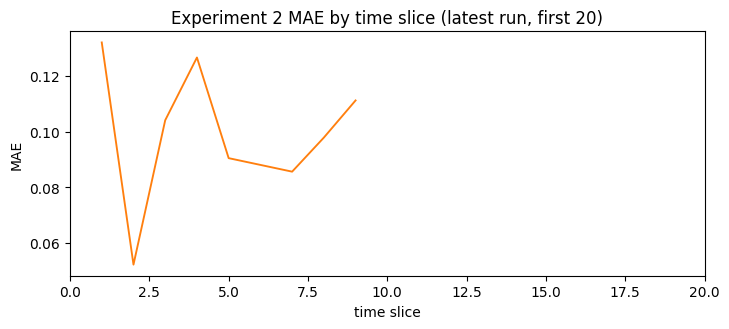

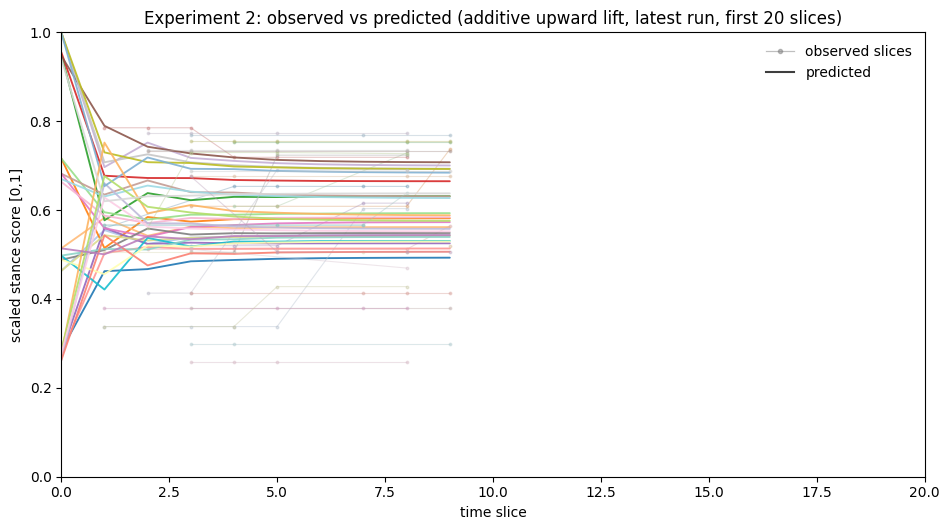

,experiment,window_slices,lambda_or_lambda_social,bias_lift,rmse_3run_window,mae_3run_window,latest_rmse_window,latest_mae_window
0,agent_specific_bias_vector,20,0.8,NaN,0.084936,0.062461,0.076307,0.059008
1,constant_global_upward_lift,20,0.8,0.2,0.136367,0.105566,0.131294,0.100908


In [5]:
rows2 = []
for lam in PARAMS['lambda_grid']:
    for delta in PARAMS['bias_lift_grid']:
        run_metrics = []
        for run_name, data in RUN_DATA.items():
            assigned_init, profile_init, init_post, base_x0 = initial_signals(data)
            out = run_fj_with_global_bias_lift(
                data,
                lam_social=lam,
                bias_lift=delta,
                base_x0_unit_dict=base_x0,
            )
            m = evaluate_records(out['records'], horizon=PARAMS['exp2_eval_horizon'])
            run_metrics.append(m)

        n_total = int(sum(m['n_eval'] for m in run_metrics))
        if n_total == 0:
            continue
        w_rmse = float(np.sqrt(np.sum([(m['rmse'] ** 2) * m['n_eval'] for m in run_metrics]) / n_total))
        w_mae = float(np.sum([m['mae'] * m['n_eval'] for m in run_metrics]) / n_total)
        rows2.append(
            {
                'lambda_social': float(lam),
                'bias_lift': float(delta),
                'rmse': w_rmse,
                'mae': w_mae,
                'n_eval': n_total,
            }
        )

exp2_res = pd.DataFrame(rows2).sort_values(['rmse', 'mae']).reset_index(drop=True)
display(exp2_res.head(10))
best2 = exp2_res.iloc[0].to_dict()
print('Best Experiment-2 params:', best2)

assigned_latest, profile_latest, init_latest, base_latest = initial_signals(latest_data)
exp2_latest_out = run_fj_with_global_bias_lift(
    latest_data,
    lam_social=best2['lambda_social'],
    bias_lift=best2['bias_lift'],
    base_x0_unit_dict=base_latest,
)
exp2_latest_df = pd.DataFrame(exp2_latest_out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
exp2_latest_metrics = evaluate_records(exp2_latest_out['records'], horizon=PARAMS['exp2_eval_horizon'])
print(f"Experiment 2 latest-run metrics (first {PARAMS['exp2_eval_horizon']} slices):", exp2_latest_metrics)

err2_df = exp2_latest_df[(exp2_latest_df['has_obs']) & (exp2_latest_df['time_slice'] <= PARAMS['exp2_plot_horizon'])].copy()
err2_df['abs_err'] = (err2_df['pred_unit'] - err2_df['obs_unit']).abs()
err2_t = err2_df.groupby('time_slice', as_index=False)['abs_err'].mean().rename(columns={'abs_err': 'mae'})

plt.figure(figsize=(7.4, 3.4))
plt.plot(err2_t['time_slice'], err2_t['mae'], color='tab:orange', linewidth=1.35)
plt.title(f"Experiment 2 MAE by time slice (latest run, first {PARAMS['exp2_plot_horizon']})")
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.xlim(0, PARAMS['exp2_plot_horizon'])
plt.tight_layout()
plt.show()

plot_all_agents(
    exp2_latest_df,
    title=f"Experiment 2: observed vs predicted (additive upward lift, latest run, first {PARAMS['exp2_plot_horizon']} slices)",
    horizon=PARAMS['exp2_plot_horizon'],
)

comparison = pd.DataFrame(
    [
        {
            'experiment': 'agent_specific_bias_vector',
            'window_slices': PARAMS['exp1_eval_horizon'],
            'lambda_or_lambda_social': best1['lambda'],
            'bias_lift': np.nan,
            'rmse_3run_window': best1['rmse'],
            'mae_3run_window': best1['mae'],
            'latest_rmse_window': exp1_latest_metrics['rmse'],
            'latest_mae_window': exp1_latest_metrics['mae'],
        },
        {
            'experiment': 'constant_global_upward_lift',
            'window_slices': PARAMS['exp2_eval_horizon'],
            'lambda_or_lambda_social': best2['lambda_social'],
            'bias_lift': best2['bias_lift'],
            'rmse_3run_window': best2['rmse'],
            'mae_3run_window': best2['mae'],
            'latest_rmse_window': exp2_latest_metrics['rmse'],
            'latest_mae_window': exp2_latest_metrics['mae'],
        },
    ]
)
display(comparison)

## Experiment 3: Transition-Fit Unclipped Agent Bias + Regression Spectrum

This section fits a per-agent bias function using **all cleaned runs** and one-step transition supervision:

- Target bias per transition comes from rearranging FJ one-step dynamics.
- Features use each agent's current state, social input, and network-level state at that slice.
- Bias is intentionally **unclipped**.
- We report model fit plus eigenvalue/eigenvector diagnostics of the ridge normal matrix inverse used in regression.

Loaded 11 runs for transition fitting.
Latest run for plotting: run_20260315-195220


,lambda,rmse,mae,dispersion_gap,objective,n_eval,n_transitions,eig_min,eig_max,cond_inv_normal
0,0.5,0.076379,0.045514,0.017062,0.079791,1272,1272,0.000218,31.669965,145246.074699
1,0.4,0.076548,0.048629,0.016853,0.079918,1272,1272,0.000218,31.669965,145246.074699
2,0.6,0.076721,0.043847,0.017079,0.080137,1272,1272,0.000218,31.669965,145246.074699
3,0.7,0.077180,0.043091,0.017041,0.080588,1272,1272,0.000218,31.669965,145246.074699
4,0.8,0.077636,0.043127,0.017000,0.081036,1272,1272,0.000218,31.669965,145246.074699
5,0.9,0.078057,0.043547,0.016961,0.081449,1272,1272,0.000218,31.669965,145246.074699
6,0.3,0.078684,0.054971,0.016210,0.081926,1272,1272,0.000218,31.669965,145246.074699
7,0.2,0.089296,0.069673,0.015658,0.092427,1272,1272,0.000218,31.669965,145246.074699
8,0.1,0.150115,0.122377,0.026418,0.155398,1272,1272,0.000218,31.669965,145246.074699


Best transition-fit model: {'lambda': 0.5, 'rmse': 0.07637886949764539, 'mae': 0.04551381196713209, 'dispersion_gap': 0.017061761229077863, 'objective': 0.07979122174346095, 'n_eval': 1272.0, 'n_transitions': 1272.0, 'eig_min': 0.0002180435197210028, 'eig_max': 31.669965352961796, 'cond_inv_normal': 145246.0746986888}
Latest-run metrics (first 20 slices): {'mae': 0.04164002390473944, 'rmse': 0.06453411330225836, 'n_eval': 119}
Latest-run dispersion gap (first 20 slices): 0.013220189151634879


,agent,bias_unit_unclipped,bias_ss_unclipped
0,agent_1,0.733698,0.467395
1,agent_2,0.225740,-0.548519
2,agent_3,0.682406,0.364813
3,agent_4,0.732238,0.464476
4,agent_5,1.021516,1.043032
5,agent_6,0.782177,0.564354
6,agent_7,0.925489,0.850978
7,agent_8,0.457766,-0.084468
8,agent_9,0.553885,0.107771
9,agent_10,0.884899,0.769797


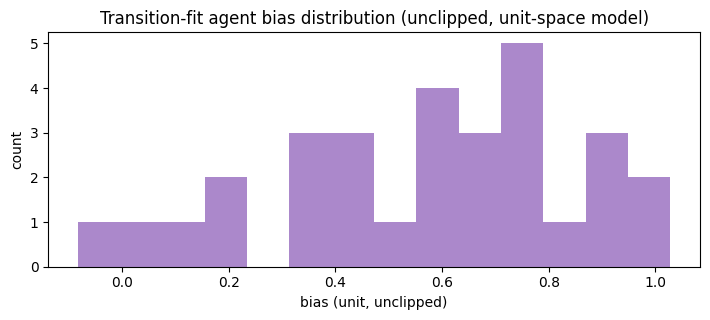

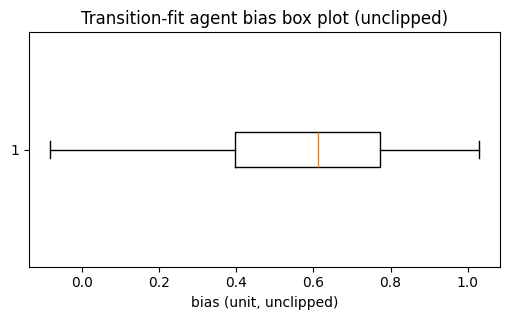

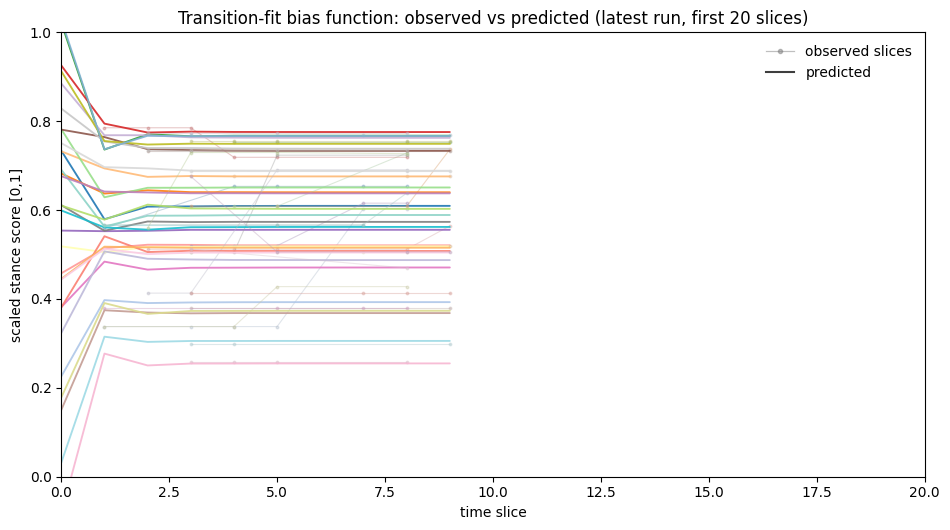

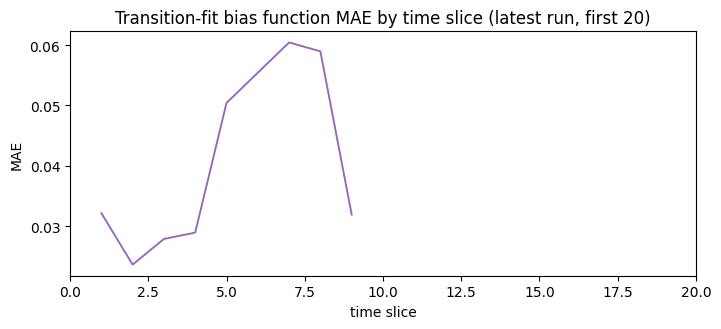

,rank,eigval_inv_normal
0,1,31.669965
1,2,20.000000
2,3,20.000000
3,4,20.000000
4,5,20.000000
5,6,20.000000
6,7,10.255998
7,8,2.919675
8,9,0.821985
9,10,0.188492


Top 15 absolute components of leading eigenvector:


,coef_index,lead_eigvec_component,abs_component
0,0,-0.614545,0.614545
1,10,0.345959,0.345959
2,9,0.303710,0.303710
3,7,0.302727,0.302727
4,30,0.189751,0.189751
5,38,0.170014,0.170014
6,22,0.165163,0.165163
7,28,0.159876,0.159876
8,36,0.138742,0.138742
9,23,0.136421,0.136421


Conclusion flags:
  numerically_stable_inverse = True
  good_fit_and_variance_match = True
Overall conclusion: regression spectrum looks stable and fit quality is strong for early-slice prediction.


In [ ]:
if 'ROOT' not in globals() or not (ROOT / 'modeling' / 'cleaned_data').exists():
    ROOT = Path('/Users/samuelli/Documents/code/llm/llm-network')
CLEAN_ALL = ROOT / 'modeling' / 'cleaned_data'
ALL_RUN_DIRS = sorted([p for p in CLEAN_ALL.glob('run_*') if p.is_dir()])
assert ALL_RUN_DIRS, f'No run_* folders found in {CLEAN_ALL}'
ALL_RUN_DATA = {r.name: load_run_data(r) for r in ALL_RUN_DIRS}
LATEST_ALL_RUN = ALL_RUN_DIRS[-1].name

print(f'Loaded {len(ALL_RUN_DATA)} runs for transition fitting.')
print('Latest run for plotting:', LATEST_ALL_RUN)


def build_state_tables(data):
    agent_ids = data['agent_ids']
    n = len(agent_ids)
    T = int(data['max_time_slice'])
    idx = {a: i for i, a in enumerate(agent_ids)}

    assigned_init, profile_init, init_post, _ = initial_signals(data)

    z = np.zeros((T + 1, n), dtype=float)
    has_obs = np.zeros((T + 1, n), dtype=bool)

    for a in agent_ids:
        z[0, idx[a]] = float(profile_init[a])

    for a in agent_ids:
        m = data['profile_by_agent_slice'].get(a, {})
        if 0 in m:
            z[0, idx[a]] = float(to_unit_interval(float(m[0])))
            has_obs[0, idx[a]] = True

    for t in range(1, T + 1):
        z[t] = z[t - 1]
        for a in agent_ids:
            m = data['profile_by_agent_slice'].get(a, {})
            if t in m:
                z[t, idx[a]] = float(to_unit_interval(float(m[t])))
                has_obs[t, idx[a]] = True

    preds = build_predecessors(data['graph'], agent_ids)
    W, _ = build_W_for_fj(preds, agent_ids)

    in_deg = {a: len(preds.get(a, [])) for a in agent_ids}
    out_deg = {a: len(data['graph'].get(a, [])) for a in agent_ids}
    max_in = max(1, max(in_deg.values()) if in_deg else 1)
    max_out = max(1, max(out_deg.values()) if out_deg else 1)

    static_feats = {
        a: {
            'assigned': float(assigned_init[a]),
            'profile_init': float(profile_init[a]),
            'init_post': float(init_post[a]),
            'in_deg': float(in_deg[a]) / float(max_in),
            'out_deg': float(out_deg[a]) / float(max_out),
        }
        for a in agent_ids
    }

    return {
        'z': z,
        'has_obs': has_obs,
        'W': W,
        'idx': idx,
        'agent_ids': agent_ids,
        'static_feats': static_feats,
    }


def transition_dataset(all_run_data, lam):
    rows = []
    agent_universe = sorted({a for d in all_run_data.values() for a in d['agent_ids']}, key=numeric_agent_key)
    agent_to_col = {a: k for k, a in enumerate(agent_universe)}

    for run_name, data in all_run_data.items():
        st = build_state_tables(data)
        z = st['z']
        has_obs = st['has_obs']
        W = st['W']
        idx = st['idx']
        agent_ids = st['agent_ids']
        sf = st['static_feats']
        T = z.shape[0] - 1

        for t in range(0, T):
            social = W @ z[t]
            net_mean = float(np.mean(z[t]))
            net_std = float(np.std(z[t]))

            for a in agent_ids:
                i = idx[a]
                if not has_obs[t + 1, i]:
                    continue

                y = (float(z[t + 1, i]) - (1.0 - float(lam)) * float(social[i])) / float(lam)
                own = float(z[t, i])

                f = np.array([
                    own,
                    float(social[i]),
                    net_mean,
                    net_std,
                    own - net_mean,
                    sf[a]['assigned'],
                    sf[a]['profile_init'],
                    sf[a]['init_post'],
                    sf[a]['in_deg'],
                    sf[a]['out_deg'],
                ], dtype=float)

                rows.append((run_name, a, t, f, y))

    if not rows:
        return None

    Xf = np.vstack([r[3] for r in rows])
    y = np.array([r[4] for r in rows], dtype=float)

    n = len(rows)
    p = Xf.shape[1]
    A = len(agent_universe)
    X = np.zeros((n, 1 + p + A), dtype=float)
    X[:, 0] = 1.0
    X[:, 1:1 + p] = Xf
    for r_i, r in enumerate(rows):
        X[r_i, 1 + p + agent_to_col[r[1]]] = 1.0

    meta = {
        'rows': rows,
        'agent_universe': agent_universe,
        'agent_to_col': agent_to_col,
        'n_features': p,
    }
    return X, y, meta


def fit_ridge(X, y, alpha=5e-2):
    XtX = X.T @ X
    reg = np.eye(X.shape[1], dtype=float) * float(alpha)
    reg[0, 0] = 0.0
    w = np.linalg.solve(XtX + reg, X.T @ y)
    return w, XtX, reg


def predict_bias_for_run(data, w, meta):
    st = build_state_tables(data)
    z0 = st['z'][0]
    W = st['W']
    idx = st['idx']
    sf = st['static_feats']
    agent_ids = st['agent_ids']

    social0 = W @ z0
    net_mean0 = float(np.mean(z0))
    net_std0 = float(np.std(z0))

    p = meta['n_features']
    agent_to_col = meta['agent_to_col']
    A = len(meta['agent_universe'])

    out = {}
    for a in agent_ids:
        i = idx[a]
        f = np.array([
            float(z0[i]),
            float(social0[i]),
            net_mean0,
            net_std0,
            float(z0[i]) - net_mean0,
            sf[a]['assigned'],
            sf[a]['profile_init'],
            sf[a]['init_post'],
            sf[a]['in_deg'],
            sf[a]['out_deg'],
        ], dtype=float)

        x = np.zeros((1 + p + A,), dtype=float)
        x[0] = 1.0
        x[1:1 + p] = f
        if a in agent_to_col:
            x[1 + p + agent_to_col[a]] = 1.0

        out[a] = float(np.dot(x, w))
    return out


def run_fj_with_bias_unclipped(data, lam, bias_dict):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    b = np.array([float(bias_dict[a]) for a in agent_ids], dtype=float)
    z = b.copy()

    records = []
    max_slice = int(data['max_time_slice'])
    for t in range(0, max_slice + 1):
        if t > 0:
            z = float(lam) * b + (1.0 - float(lam)) * (W @ z)

        for a in agent_ids:
            obs_map = data['profile_by_agent_slice'].get(a, {})
            has_obs = t in obs_map
            if has_obs:
                obs_ss = float(obs_map[t])
                obs_unit = float(to_unit_interval(obs_ss))
            else:
                obs_ss = np.nan
                obs_unit = np.nan

            pred_unit = float(z[idx[a]])
            records.append(
                {
                    'run': data['run_name'],
                    'time_slice': int(t),
                    'agent': a,
                    'pred_unit': pred_unit,
                    'obs_unit': obs_unit,
                    'pred_ss': float(2.0 * pred_unit - 1.0),
                    'obs_ss': float(obs_ss) if np.isfinite(obs_ss) else np.nan,
                    'has_obs': bool(has_obs),
                }
            )

    return {'records': records, 'bias': {a: float(bias_dict[a]) for a in agent_ids}, 'W': W, 'idx': idx}


def dispersion_gap(records, horizon=20):
    df = pd.DataFrame(records)
    df = df[(df['has_obs']) & (df['time_slice'] <= int(horizon))].copy()
    if df.empty:
        return np.nan

    gaps = []
    for _, g in df.groupby('time_slice'):
        if len(g) < 2:
            continue
        gaps.append(abs(float(g['pred_unit'].std(ddof=0)) - float(g['obs_unit'].std(ddof=0))))

    return float(np.mean(gaps)) if gaps else np.nan


lam_grid = sorted(set(PARAMS.get('lambda_grid', [0.2, 0.4, 0.6, 0.8]) + [0.1, 0.3, 0.5, 0.7, 0.9]))
alpha = 5e-2
dispersion_weight = 0.20
eval_h = int(PARAMS.get('exp1_eval_horizon', 20))

model_rows = []
fitted = {}
for lam in lam_grid:
    if lam <= 0:
        continue

    ds = transition_dataset(ALL_RUN_DATA, lam=lam)
    if ds is None:
        continue
    X, y, meta = ds

    w, XtX, reg = fit_ridge(X, y, alpha=alpha)

    run_metrics = []
    run_disp = []
    run_bias = {}
    for run_name, data in ALL_RUN_DATA.items():
        b = predict_bias_for_run(data, w=w, meta=meta)
        out = run_fj_with_bias_unclipped(data, lam=lam, bias_dict=b)
        m = evaluate_records(out['records'], horizon=eval_h)
        dgap = dispersion_gap(out['records'], horizon=eval_h)
        run_metrics.append(m)
        run_disp.append(dgap if np.isfinite(dgap) else 0.0)
        run_bias[run_name] = b

    n_total = int(sum(m['n_eval'] for m in run_metrics))
    if n_total == 0:
        continue

    w_rmse = float(np.sqrt(np.sum([(m['rmse'] ** 2) * m['n_eval'] for m in run_metrics]) / n_total))
    w_mae = float(np.sum([m['mae'] * m['n_eval'] for m in run_metrics]) / n_total)
    mean_disp_gap = float(np.mean(run_disp))
    objective = float(w_rmse + dispersion_weight * mean_disp_gap)

    # Stability spectrum for (X^T X + reg)^(-1)
    inv_normal = np.linalg.inv(XtX + reg)
    eigvals, eigvecs = np.linalg.eigh(inv_normal)
    eigvals = np.real(eigvals)

    model_rows.append(
        {
            'lambda': float(lam),
            'rmse': w_rmse,
            'mae': w_mae,
            'dispersion_gap': mean_disp_gap,
            'objective': objective,
            'n_eval': n_total,
            'n_transitions': int(X.shape[0]),
            'eig_min': float(np.min(eigvals)),
            'eig_max': float(np.max(eigvals)),
            'cond_inv_normal': float(np.max(eigvals) / max(np.min(eigvals), 1e-15)),
        }
    )

    fitted[float(lam)] = {
        'w': w,
        'meta': meta,
        'bias_by_run': run_bias,
        'eigvals': eigvals,
        'eigvecs': eigvecs,
        'XtX': XtX,
        'reg': reg,
    }

model_df = pd.DataFrame(model_rows).sort_values(['objective', 'rmse', 'mae']).reset_index(drop=True)
display(model_df)

best = model_df.iloc[0].to_dict()
best_lam = float(best['lambda'])
print('Best transition-fit model:', best)

latest_data_all = ALL_RUN_DATA[LATEST_ALL_RUN]
best_bias_latest = fitted[best_lam]['bias_by_run'][LATEST_ALL_RUN]
best_out_latest = run_fj_with_bias_unclipped(latest_data_all, lam=best_lam, bias_dict=best_bias_latest)
best_df_latest = pd.DataFrame(best_out_latest['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
best_metrics_latest = evaluate_records(best_out_latest['records'], horizon=eval_h)
best_disp_latest = dispersion_gap(best_out_latest['records'], horizon=eval_h)
print(f'Latest-run metrics (first {eval_h} slices):', best_metrics_latest)
print(f'Latest-run dispersion gap (first {eval_h} slices):', best_disp_latest)


bias_latest_df = pd.DataFrame(
    {
        'agent': list(best_bias_latest.keys()),
        'bias_unit_unclipped': [best_bias_latest[a] for a in best_bias_latest.keys()],
    }
).sort_values('agent', key=lambda s: s.map(numeric_agent_key)).reset_index(drop=True)
bias_latest_df['bias_ss_unclipped'] = 2.0 * bias_latest_df['bias_unit_unclipped'] - 1.0
display(bias_latest_df)

plt.figure(figsize=(7.2, 3.3))
plt.hist(bias_latest_df['bias_unit_unclipped'], bins=14, color='tab:purple', alpha=0.78)
plt.title('Transition-fit agent bias distribution (unclipped, unit-space model)')
plt.xlabel('bias (unit, unclipped)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2, 3.3))
plt.boxplot(bias_latest_df['bias_unit_unclipped'].to_numpy(dtype=float), vert=False)
plt.title('Transition-fit agent bias box plot (unclipped)')
plt.xlabel('bias (unit, unclipped)')
plt.tight_layout()
plt.show()

plot_all_agents(
    best_df_latest,
    title=f'Transition-fit bias function: observed vs predicted (latest run, first {eval_h} slices)',
    horizon=eval_h,
)

e = best_df_latest[(best_df_latest['has_obs']) & (best_df_latest['time_slice'] <= eval_h)].copy()
e['abs_err'] = (e['pred_unit'] - e['obs_unit']).abs()
e_t = e.groupby('time_slice', as_index=False)['abs_err'].mean().rename(columns={'abs_err': 'mae'})

plt.figure(figsize=(7.4, 3.4))
plt.plot(e_t['time_slice'], e_t['mae'], color='tab:purple', linewidth=1.35)
plt.title(f'Transition-fit bias function MAE by time slice (latest run, first {eval_h})')
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.xlim(0, eval_h)
plt.tight_layout()
plt.show()

# Eigen diagnostics for selected model
best_eigvals = fitted[best_lam]['eigvals']
best_eigvecs = fitted[best_lam]['eigvecs']
order = np.argsort(best_eigvals)[::-1]

top_k = min(10, len(best_eigvals))
eig_diag_df = pd.DataFrame(
    {
        'rank': np.arange(1, top_k + 1),
        'eigval_inv_normal': best_eigvals[order[:top_k]],
    }
)
display(eig_diag_df)

lead_vec = best_eigvecs[:, order[0]]
lead_vec_df = pd.DataFrame({'coef_index': np.arange(len(lead_vec)), 'lead_eigvec_component': lead_vec})
lead_vec_df['abs_component'] = lead_vec_df['lead_eigvec_component'].abs()
lead_vec_df = lead_vec_df.sort_values('abs_component', ascending=False).reset_index(drop=True)
print('Top 15 absolute components of leading eigenvector:')
display(lead_vec_df.head(15))

#